# Evaluation and Visualization for Clustering


#### Environment Setup

In [12]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Add custom module path
import sys
sys.path.append("./src/semantic")

# Standard library imports
import re

# Third-party library imports
import numpy as np
import pickle
import pandas as pd
from scipy.spatial.distance import cosine
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

# Semantic analysis scripts
from src.semantic.perform_clustering import (
    run_all_clustering, 
    run_kimchi_cos,
    run_all_clustering_with_pca
)
from src.semantic.utils.evaluate_clustering import (
    calculate_clustering_consistency,
    get_primary_category,
    map_clustering_category,
)


## Explore Different Measures of Semantic Distance

### Text Embedding

In [3]:
# Path to the category data file
category_file = './/data//wikispeedia//wikispeedia_paths-and-graph//categories.tsv'

## All paths to the embedding data files
# This time we use the new embedding data, generated with the first paragraph for each article.
MiniLM_file = './/new_data_cleaning//pca_MiniLM_dimensions.pkl' 
mpnet_file = './/new_data_cleaning//pca_mpnet_dimensions.pkl' 
roberta_file = './/new_data_cleaning//pca_Roberta_dimensions.pkl'

In [4]:
with open(MiniLM_file, "rb") as file:
        MiniLM_embedding = pickle.load(file)
        MiniLM_values = list(MiniLM_embedding.values())
with open(mpnet_file, "rb") as file:
        mpnet_embedding = pickle.load(file)
        mpnet_values = list(mpnet_embedding.values())
with open(roberta_file, "rb") as file:
        roberta_embedding = pickle.load(file)
        roberta_values = list(roberta_embedding.values())

## Semantic Measure Evaluation: Clustering on Embeddings

In [5]:
# For embeddings generated from MiniLM
print('------Starting clustering for embeddings based on MiniLM_L6_v2...')
MiniLM_clustering = run_all_clustering(MiniLM_file, category_file)
print(f"Perform {list(MiniLM_clustering.keys())} successfully!")

# For embeddings generated from mpnet_base_v2
print('------Starting clustering for embeddings based on mpnet_base_v2...')
mpnet_clustering = run_all_clustering(mpnet_file, category_file)
print(f"Perform {list(mpnet_clustering.keys())} successfully!")

# Cluster embeddings generated from roberta
print('------Starting clustering for embeddings based on roberta...')
roberta_clustering = run_all_clustering(roberta_file, category_file)
print(f"Perform {list(roberta_clustering.keys())} successfully!")

------Starting clustering for embeddings based on MiniLM_L6_v2...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!
------Starting clustering for embeddings based on mpnet_base_v2...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:01<00:00,  1.80it/s]


Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!
------Starting clustering for embeddings based on roberta...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:00<00:00,  3.33it/s]

Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!


the clustering results is stored as follows:

- **MiniLM_clustering**
  - **K-Medoids Manhattan**: Embeddings (DataFrame)
  - **K-Medoids Cosine**: Embeddings (DataFrame)

In [6]:
# A sample of clustering results
MiniLM_clustering['K-Medoids_Manhattan'].head(5)

,concept,clustering
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,0
1,%C3%85land,0
2,%C3%89douard_Manet,1
3,%C3%89ire,6
4,%C3%93engus_I_of_the_Picts,0


### Category-Cluster Mapping and Evaluation


- This method calculates the accuracy and weighted F1 score for the Category-Cluster Mapping. 
- First, the cluster-category mapping is sorted in descending order based on their mapping counts and then uniquely matched (each cluster corresponds to only one category, and each category corresponds to only one cluster).
- **Accuracy** is calculated as the proportion of matched articles in the Category-Cluster Mapping out of all articles; higher values are better as they indicate more accurate clustering. 
- **Weighted F1 score** accounts for the varying sizes of different categories, providing a more comprehensive evaluation of the clustering results; higher values are preferred as they reflect better overall performance.
- **Purity** indicates the extent to which each cluster contains points from a single ground truth class; higher values are better as they signify cleaner and more distinct clusters.
- **Entropy** quantifies the randomness or disorder within the clustering; lower values are better as they indicate more consistent and cohesive clusters.


In [7]:
# Get primary categories for concepts and show the head
primary_category = get_primary_category(category_file)
primary_category.head(5)

,concept,primary_category
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,History
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,People
2,%C3%85land,Countries
3,%C3%85land,Geography
4,%C3%89douard_Manet,People


In [8]:
# Set dicts to save the mapping results
MiniLM_evaluation = {}
mpnet_evaluation = {}
roberta_evaluation = {}
MiniLM_mapping = {}
mpnet_mapping = {}
roberta_mapping = {}

# Set df to save the evaluation results
MiniLM_eva_df = pd.DataFrame(columns=['accuracy','weighted_F1','purity','entropy'])
mpnet_eva_df = pd.DataFrame(columns=['accuracy','weighted_F1','purity','entropy'])
roberta_eva_df = pd.DataFrame(columns=['accuracy','weighted_F1','purity','entropy'])

# evaluation on MiniLM_L6_v2
print("------Evaluation results for MiniLM embeddings:")
for key, value in MiniLM_clustering.items():
    cluster_category_mapping, merged_df, accuracy, weighted_f1, purity,entropy = map_clustering_category(primary_category, value)
    MiniLM_mapping[key] = cluster_category_mapping
    MiniLM_evaluation[key] = merged_df
    MiniLM_eva_df.loc[len(MiniLM_eva_df)] = [accuracy, weighted_f1, purity,entropy]
    
MiniLM_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(MiniLM_eva_df)

# evaluation on mpnet_base_v2
print("------Evaluation results for mpnet embeddings:")
for key, value in mpnet_clustering.items():
    cluster_category_mapping, merged_df, accuracy, weighted_f1, purity,entropy = map_clustering_category(primary_category, value)
    mpnet_mapping[key] = cluster_category_mapping
    mpnet_evaluation[key] = merged_df
    mpnet_eva_df.loc[len(mpnet_eva_df)] = [accuracy, weighted_f1, purity,entropy]
mpnet_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(mpnet_eva_df)

# evaluation on mpnet_base_v2
print("------Evaluation results for roberta embeddings:")
for key, value in roberta_clustering.items():
    cluster_category_mapping, merged_df, accuracy, weighted_f1, purity,entropy = map_clustering_category(primary_category, value)
    roberta_mapping[key] = cluster_category_mapping
    roberta_evaluation[key] = merged_df
    roberta_eva_df.loc[len(roberta_eva_df)] = [accuracy, weighted_f1, purity,entropy]
roberta_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(roberta_eva_df)

------Evaluation results for MiniLM embeddings:
                     accuracy  weighted_F1    purity   entropy
K-Medoids_Manhattan  0.181783     0.209239  0.350692  2.821583
K-Medoids_Cosine     0.338970     0.381273  0.459839  2.360897
------Evaluation results for mpnet embeddings:
                     accuracy  weighted_F1    purity   entropy
K-Medoids_Manhattan  0.206188     0.220745  0.378939  2.787256
K-Medoids_Cosine     0.294581     0.343622  0.512683  2.248699
------Evaluation results for roberta embeddings:
                     accuracy  weighted_F1    purity   entropy
K-Medoids_Manhattan  0.152191      0.17292  0.328786  2.973449
K-Medoids_Cosine     0.212529      0.24173  0.446003  2.553098


Based on the evaluataion results, we finally choose **MiniLM embeddings** with the **Cosine Distance** as our semantic distance.

## Visualize the clustering result

In [ ]:
## As an embedding has many dimensions, we can select two dimensions and draw the distribution.
# Choose two dimensions: d1, d2. We can set two dimensions freely.
d1=0
d2=1
MiniLM_values_array = np.array(MiniLM_values)[:, [d1, d2]]
MiniLM_df = pd.DataFrame(MiniLM_values_array, columns=["d1", "d2"])
MiniLM_df['clustering'] = MiniLM_clustering['K-Medoids_Cosine']['clustering']
MiniLM_df['clustering'] = MiniLM_df['clustering'].apply(lambda x: str(x)+'-'+MiniLM_mapping['K-Medoids_Cosine'][x])
# A sample of the data
MiniLM_df.head(5)

,d1,d2,clustering
0,0.124360,-0.289156,13-History
1,-0.265809,-0.242378,1-Religion
2,0.375082,-0.053796,6-People
3,0.010349,-0.186924,13-History
4,0.061973,-0.181092,13-History


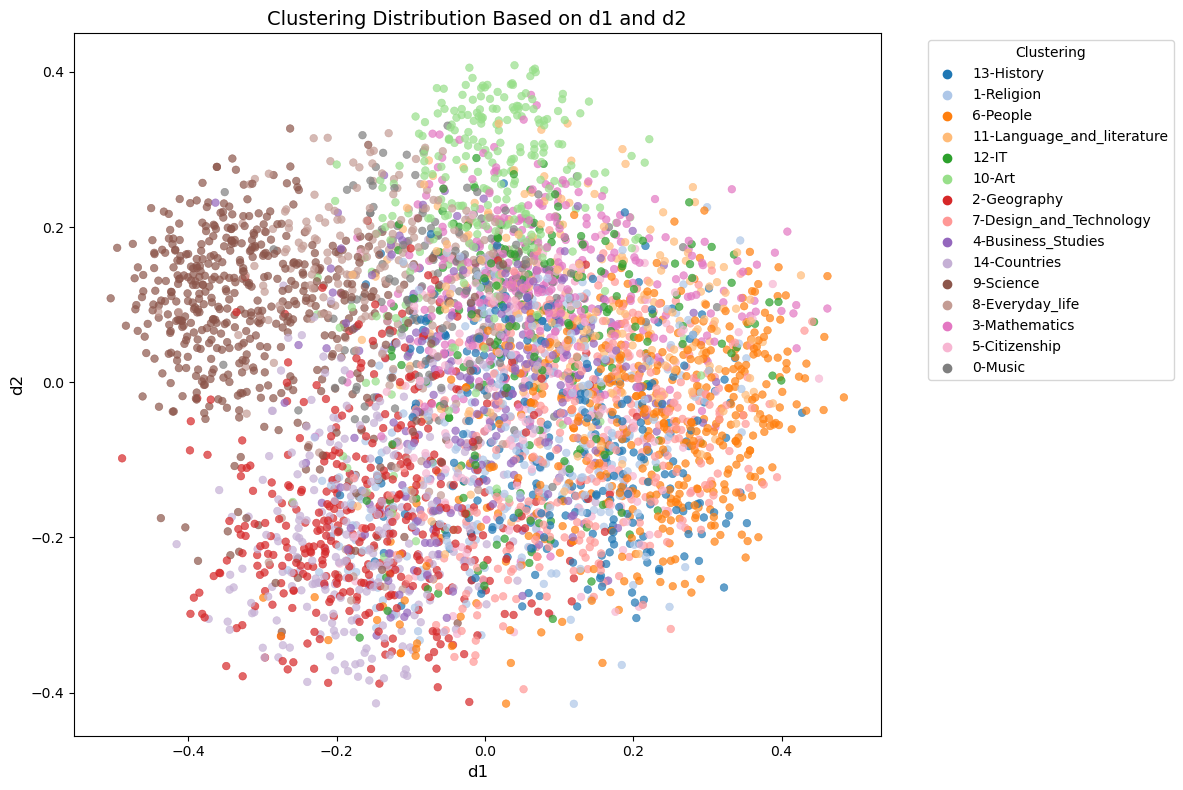

In [10]:
# Plot a scatter plot using Seaborn
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='d1',                     # Use 'd1' for the x-axis
    y='d2',                     # Use 'd2' for the y-axis
    hue='clustering',           # Color points based on the 'clustering' column
    palette='tab20',             # Use the 'husl' palette for distinct and rich colors
    data=MiniLM_df,             # Input DataFrame
    s=30,                       # Adjust the point size
    alpha=0.7,                  # Set transparency to avoid excessive overlap
    edgecolor=None              # Remove the border around points
)

# Add titles and axis labels
plt.title('Clustering Distribution Based on d1 and d2', fontsize=14)
plt.xlabel('d1', fontsize=12)
plt.ylabel('d2', fontsize=12)

# Adjust the legend position for better visibility
plt.legend(title='Clustering', bbox_to_anchor=(1.05, 1), loc='upper left')

# Optimize layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Visualize the semantic path
We can use the cosine distance to represent the semantic distance and visualize each navigation.

In [ ]:
# First we need to calculate the semantic distance between each two concepts
# Extract concept names and embeddings
concept_names = list(MiniLM_embedding.keys())
embeddings = np.array(list(MiniLM_embedding.values()))

# Create an empty list to store results
results = []

# Compute cosine distances between every pair of concepts
num_concepts = len(concept_names)
for i in range(num_concepts):
    for j in range(i + 1, num_concepts):  # Ensure (a, b) is not duplicated as (b, a)
        concept_1 = concept_names[i]
        concept_2 = concept_names[j]
        distance = cosine(embeddings[i], embeddings[j])
        results.append((concept_1, concept_2, distance))

# Convert results to a DataFrame
distance_df = pd.DataFrame(results, columns=["Concept 1", "Concept 2", "Distance"])

# Save the data 
# distance_df.to_csv('new_data_cleaning//semantic_distance.csv',index=False,encoding='utf-8-sig')

In [ ]:
# Define the file path
file_path = "data//wikispeedia//wikispeedia_paths-and-graph//paths_finished.tsv"  # Replace with your file path

# Read the data: skip lines starting with "#" (comments)
path_df = pd.read_csv(file_path, sep='\t', comment='#', header=None, 
                      names=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"])

# Replace "NULL" with NaN to handle missing values
path_df["rating"] = path_df["rating"].replace("NULL", pd.NA)

# Print the first 3 rows of the DataFrame
path_df.head(3)

,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN


In [40]:
# Example dataset containing paths

# Calculate the length of each path (number of concepts separated by ";")
path_df['path_length'] = path_df['path'].apply(lambda x: len(x.split(';')))

# Count the number of paths for each length
length_counts = path_df['path_length'].value_counts().sort_index()
length_counts = length_counts[length_counts>2000]

# Print the results
print("Path length counts:")
print(length_counts)

Path length counts:
3     3424
4     8558
5    10941
6     8137
7     5868
8     3954
9     2650
Name: path_length, dtype: int64


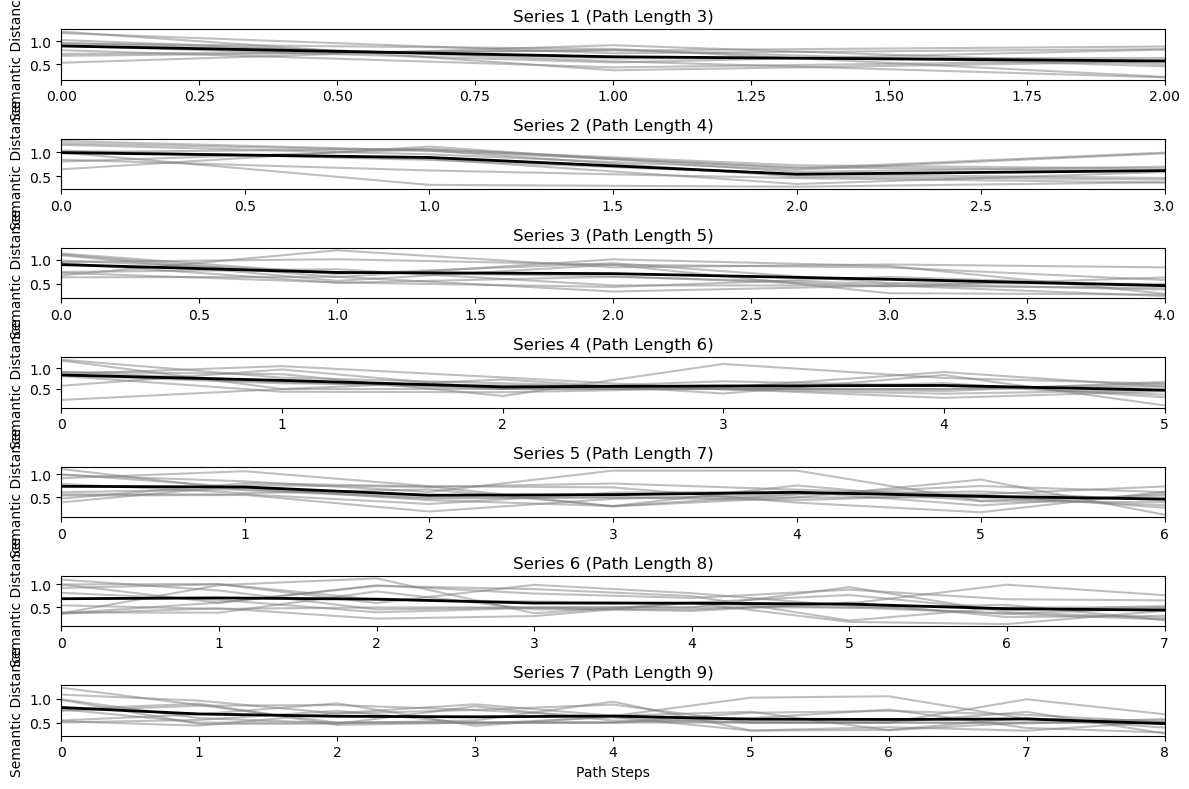

In [ ]:
# Convert semantic distance data to a dictionary for fast lookups
distance_dict = {}
for _, row in distance_df.iterrows():
    distance_dict[(row['Concept 1'], row['Concept 2'])] = row['Distance']
    distance_dict[(row['Concept 2'], row['Concept 1'])] = row['Distance']  # Ensure symmetry

# Compute semantic distances for each path
def compute_path_distances(path, distance_dict, default_distance=0.5):
    concepts = path.split(';')
    distances = []
    for i in range(len(concepts) - 1):
        concept_pair = (concepts[i], concepts[i + 1])
        distance = distance_dict.get(concept_pair, default_distance)  # Use default if pair not found
        distances.append(distance)
    return distances

# Process all paths and group them by path length
path_lengths = []
path_distances = []
for path in path_df['path']:
    distances = compute_path_distances(path, distance_dict)
    path_lengths.append(len(distances))  # Length is the number of distances
    path_distances.append(distances)

# Convert path lengths and distances into a DataFrame for easy sampling
path_data = pd.DataFrame({'length': path_lengths, 'distances': path_distances})

# Filter paths to include only specified lengths and sample 10 paths for each length
filtered_lengths = [3, 4, 5, 6, 7, 8, 9]
sampled_paths = (
    path_data[path_data['length'].isin(filtered_lengths)]
    .groupby('length')
    .apply(lambda x: x.sample(min(len(x), 10), random_state=42))
    .reset_index(drop=True)
)

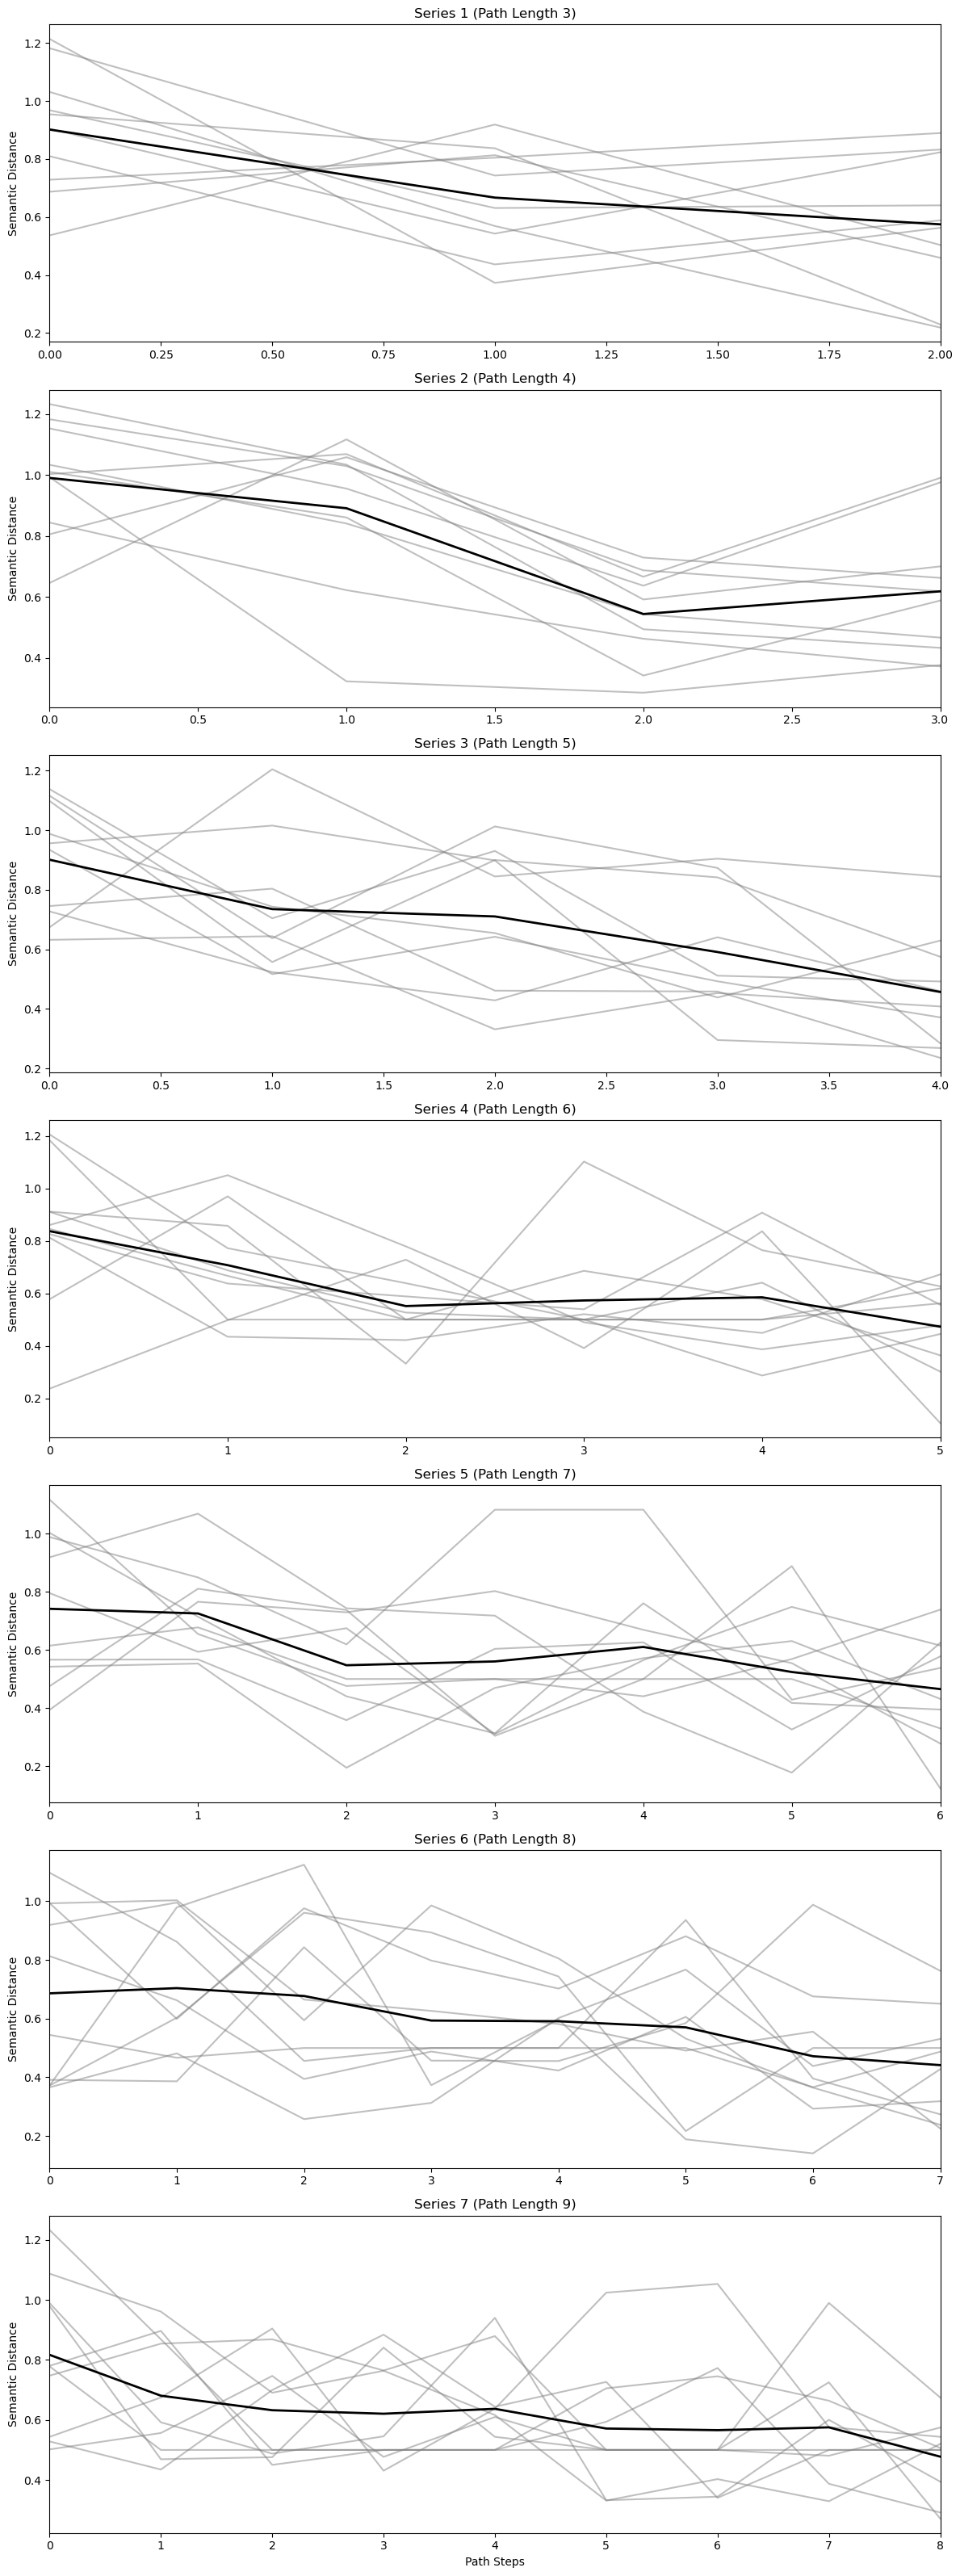

In [42]:
# Visualization
# Group sampled paths by their lengths
unique_lengths = sorted(sampled_paths['length'].unique())

plt.figure(figsize=(12, 32))  # Overall figure size

# Plot each group in a subplot
for idx, length in enumerate(unique_lengths):
    plt.subplot(len(unique_lengths), 1, idx + 1)
    plt.title(f"Series {idx + 1} (Path Length {length})")
    
    # Extract paths of this length
    length_group = sampled_paths[sampled_paths['length'] == length]['distances']
    
    # Plot sampled paths
    for distances in length_group:
        plt.plot(distances, color='gray', alpha=0.5)  # Plot background paths
    
    # Highlight the average path
    avg_distances = np.mean(length_group.tolist(), axis=0)
    plt.plot(avg_distances, color='black', linewidth=2)  # Highlight average line
    
    plt.xlim(0, length - 1)
    plt.ylabel('Semantic Distance')

# Add x-axis label
plt.xlabel('Path Steps')
plt.tight_layout()
plt.show()

The following part: Calculating intra-cluster and inter-cluster distance is abandoned.
Cause the results are so weird.

**Intra-cluster and Inter-cluster Distance**

We want distances between clusters to be as large as possible. 

We want distances between points within a cluster to be as small as possible.

In [ ]:
def calculate_cluster_distances(data, labels, num_clusters):

    cluster_centers = []
    intra_cluster_distances = []

    # Calculate cluster centers and intra-cluster distances
    for cluster_id in range(num_clusters):
        cluster_points = data[labels == cluster_id]  # Extract points in the current cluster
        if len(cluster_points) > 0:
            cluster_center = cluster_points.mean(axis=0)  # Compute cluster center
            cluster_centers.append(cluster_center)

            # Compute distances within the cluster (point-to-center distances)
            intra_distances = cdist(cluster_points, [cluster_center])  # Pairwise distances
            intra_cluster_distances.append(np.mean(intra_distances))
        else:
            # Handle empty clusters if they exist
            cluster_centers.append(np.zeros(data.shape[1]))
            intra_cluster_distances.append(0.0)

    # Convert cluster centers to a NumPy array
    cluster_centers = np.array(cluster_centers)

    # Compute inter-cluster distances
    inter_cluster_distances = cdist(cluster_centers, cluster_centers)  # Pairwise distances between centers
    np.fill_diagonal(inter_cluster_distances, 0)  # Ignore self-distances

    # Average distances
    avg_inter_cluster_distance = np.sum(inter_cluster_distances) / (num_clusters * (num_clusters - 1))
    avg_intra_cluster_distance = np.mean(intra_cluster_distances)

    return avg_inter_cluster_distance, avg_intra_cluster_distance

# Compute distances
data = np.array(MiniLM_values)
labels = MiniLM_clustering['K-Medoids_Manhattan']['clustering'].tolist()
avg_inter_dist, avg_intra_dist = calculate_cluster_distances(data, labels, 15)

# Output results
print(f"Average Inter-Cluster Distance: {avg_inter_dist:.8f}")
print(f"Average Intra-Cluster Distance: {avg_intra_dist:.8f}")

Average Inter-Cluster Distance: 0.00000000
Average Intra-Cluster Distance: 0.00000000
